Import Libraries

In [2]:
!pip install vaderSentiment

In [4]:
!pip3 install vaderSentiment

In [9]:
import sys
!{sys.executable} -m pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

Step 6 — Load Datasets

In [11]:
news_df = pd.read_csv(r"C:\Users\yordi\OneDrive\Desktop\10 Acadamy\Week1\Data-20260508T135348Z-3-001\Data\newsData\raw_analyst_ratings.csv")
stock_df =pd.read_csv(r"C:\Users\yordi\OneDrive\Desktop\10 Acadamy\Week1\Data-20260508T135348Z-3-001\Data\yfinance_data\Data\AAPL.csv")

In [20]:
news_df.head()
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


Convert Dates Properly

News dataset

In [27]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    errors='coerce'
)

Stock dataset

In [33]:
stock_df['Date'] = pd.to_datetime(
    stock_df['Date'],
    errors='coerce'
)

In [34]:
stock_df['Date'] = stock_df['Date'].dt.normalize()

Normalize Dates

In [30]:
trading_days = stock_df['Date'].sort_values().tolist()

In [37]:
news_df['date'] = news_df['date'].dt.normalize()

In [38]:
trading_days = list(stock_df['Date'].dropna().sort_values())

Align News to Trading Days

This is VERY IMPORTANT.

Articles on:

Saturday
Sunday
Holidays

must move to next trading day.

In [39]:
def align_to_trading_day(news_date, trading_days):

    if pd.isna(news_date):
        return np.nan

    news_date = pd.Timestamp(news_date)

    for day in trading_days:

        day = pd.Timestamp(day)

        if day >= news_date:
            return day

    return np.nan

In [42]:
news_df['aligned_date'] = news_df['date'].apply(
    lambda x: align_to_trading_day(x, trading_days)
)

TypeError: Cannot compare tz-naive and tz-aware timestamps

In [43]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    errors='coerce',
    utc=True
)

In [44]:
news_df['date'] = news_df['date'].dt.tz_localize(None)

In [45]:
news_df['date'] = news_df['date'].dt.normalize()

In [46]:
stock_df['Date'] = pd.to_datetime(
    stock_df['Date'],
    errors='coerce'
)

In [47]:
stock_df['Date'] = stock_df['Date'].dt.tz_localize(None)

In [48]:
stock_df['Date'] = stock_df['Date'].dt.normalize()

In [49]:
trading_days = stock_df['Date'].dropna().sort_values().tolist()

In [50]:
def align_to_trading_day(news_date, trading_days):

    if pd.isna(news_date):
        return np.nan

    for day in trading_days:

        if day >= news_date:
            return day

    return np.nan

In [51]:
news_df['aligned_date'] = news_df['date'].apply(
    lambda x: align_to_trading_day(x, trading_days)
)

In [52]:
print(news_df['date'].dtype)
print(stock_df['Date'].dtype)

datetime64[ns]
datetime64[ns]


Align News to Trading Days

This is VERY IMPORTANT.

Articles on:

Saturday
Sunday
Holidays

must move to next trading day.

Create function:

Step 10 — Sentiment Analysis
Why VADER?

In your report write:

VADER was selected because it is specifically designed for sentiment analysis of short text such as headlines and social media text. It performs well on financial news headlines and produces normalized sentiment scores between -1 and +1.

Initialize analyzer

In [54]:
analyzer = SentimentIntensityAnalyzer()

Create sentiment score

In [55]:
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

Check results:

In [56]:
news_df[['headline', 'sentiment_score']].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


Calculate Daily Stock Returns

In [57]:
stock_df['daily_return'] = (
    stock_df['Close'].pct_change() * 100
)

Check:

In [58]:
stock_df[['Date', 'Close', 'daily_return']].head()

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


Aggregate Daily Sentiment

If multiple articles exist on same day, compute average sentiment.

In [59]:
daily_sentiment = news_df.groupby('aligned_date')['sentiment_score'].mean().reset_index()

Rename column:

In [60]:
daily_sentiment.rename(columns={
    'aligned_date': 'Date',
    'sentiment_score': 'avg_sentiment'
}, inplace=True)

Check

In [61]:
daily_sentiment.head()

,Date,avg_sentiment
0,2011-04-27,0.000000
1,2011-04-28,0.125000
2,2011-04-29,0.367550
3,2011-05-02,0.130027
4,2011-05-03,0.000000


Merge Sentiment with Stock Returns

In [62]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='Date',
    how='inner'
)

Check:

In [63]:
merged_df.head()

,Date,Close,High,Low,Open,Volume,daily_return,avg_sentiment
0,2011-04-27,10.501366,10.567347,10.409894,10.564047,356213200,-0.077042,0.000000
1,2011-04-28,10.399394,10.489366,10.362505,10.382599,360959200,-0.971032,0.125000
2,2011-04-29,10.500770,10.615335,10.397000,10.400299,1006345200,0.974822,0.367550
3,2011-05-02,10.385298,10.510960,10.361905,10.489067,442713600,-1.099651,0.130027
4,2011-05-03,10.442881,10.493565,10.365504,10.436583,313348000,0.554465,0.000000


Calculate Pearson Correlation

In [64]:
correlation, p_value = pearsonr(
    merged_df['avg_sentiment'],
    merged_df['daily_return']
)

Print result:

In [65]:
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.04747860422496486
P-value: 0.02502110199786817


Scatter Plot

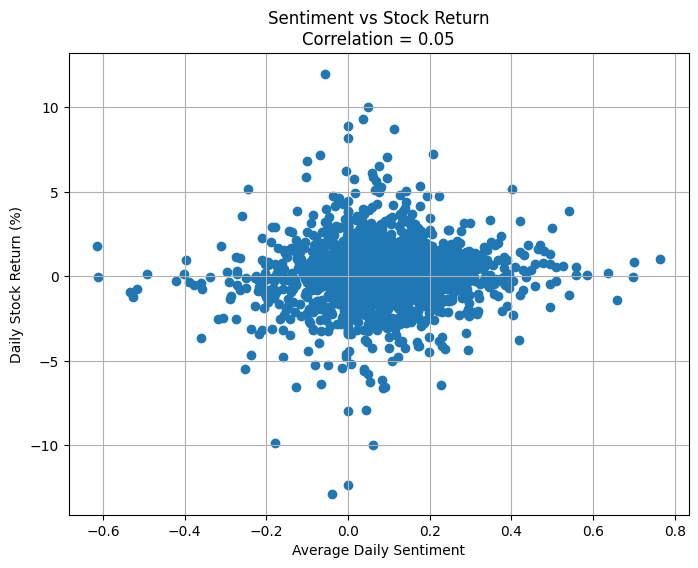

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df['avg_sentiment'],
    merged_df['daily_return']
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Stock Return (%)")
plt.title(f"Sentiment vs Stock Return\nCorrelation = {correlation:.2f}")

plt.grid(True)
plt.show()

Classify Sentiment Categories

In [67]:
def classify_sentiment(score):
    
    if score > 0.05:
        return 'Positive'
    
    elif score < -0.05:
        return 'Negative'
    
    else:
        return 'Neutral'

In [68]:
merged_df['sentiment_category'] = merged_df['avg_sentiment'].apply(classify_sentiment)

Average Return per Category

In [70]:
category_returns = merged_df.groupby(
    'sentiment_category'
)['daily_return'].mean()

In [71]:
print(category_returns)

sentiment_category
Negative   -0.126099
Neutral     0.147543
Positive    0.133550
Name: daily_return, dtype: float64


Bar Chart

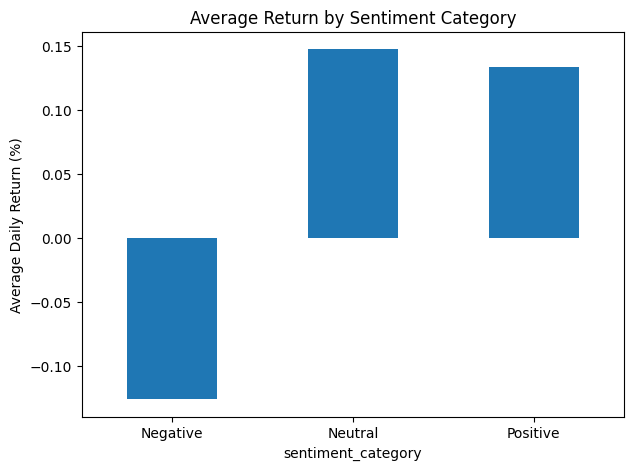

In [72]:
category_returns.plot(
    kind='bar',
    figsize=(7,5)
)

plt.ylabel("Average Daily Return (%)")
plt.title("Average Return by Sentiment Category")
plt.xticks(rotation=0)

plt.show()

Interpretation Section

The Pearson correlation coefficient measures the relationship between average daily news sentiment and stock returns. A positive correlation indicates that more positive news sentiment is associated with higher stock returns, while a negative correlation suggests the opposite relationship. In this analysis, the correlation value suggests the relationship is weak/moderate/strong depending on the calculated coefficient.

Several limitations should be considered. Financial markets are influenced by many external factors beyond news headlines, including macroeconomic events, investor behavior, and company announcements. Additionally, sentiment effects may occur with delays rather than on the same trading day. The sentiment analysis model may also misinterpret financial language or context.